# 02 — Cleaning & Validation

In [ ]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import src.config as cfg
import src.clean as clean
import src.features as feat

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
np.random.seed(cfg.RANDOM_SEED)

In [10]:
import src.run_pipeline as run_pipeline
from src.validate import validate_all

posts_raw = clean.load_raw(cfg.RAW_POSTS)
users_raw = clean.load_raw(cfg.RAW_USERS)
print(f"raw posts {posts_raw.shape}   raw users {users_raw.shape}")

raw posts (12360, 8)   raw users (1500, 5)


## 1. Rule-by-rule demonstration

Each rule shown on the rows it actually affects, so the transformation is visible
rather than asserted.

### D1 — dual sentinel encoding → a single `pd.NA`

In [5]:
probe = ["", "NULL", "null", "  NULL  ", "N/A", "-", "Nike", "0", "NULLIFY"]
pd.DataFrame({"value": probe, "is_sentinel": [clean.is_sentinel(v) for v in probe]})

,value,is_sentinel
0,,True
1,NULL,True
2,null,True
3,NULL,True
4,N/A,True
5,-,True
6,Nike,False
7,0,False
8,NULLIFY,False


`NULLIFY` correctly survives: matching is on the **whole stripped cell**, never a
substring.

### D5b + D3–D6 — text repair, in order

In [6]:
examples = [
    "Bummed out with my new Air Max from Nike!<div>",
    "Great value #Fashion&amp;",
    "Just tried the Pixel 8. Superbe caf\u00c3\u00a9 vibes. #Travel\u00c3\u00a9",
    "NULL<div>",
    "  too   many    spaces  ",
]
pd.DataFrame({
    "before": examples,
    "after":  [clean.clean_text(e) for e in examples],
}).style.set_properties(**{"text-align": "left"})

,before,after
0,Bummed out with my new Air Max from Nike!,Bummed out with my new Air Max from Nike!
1,Great value #Fashion&,Great value #Fashion
2,Just tried the Pixel 8. Superbe cafÃ© vibes. #TravelÃ©,Just tried the Pixel 8. Superbe café vibes. #Travel
3,NULL,
4,too many spaces,too many spaces


Row 3 is the ordering proof: the in-sentence `Ã©` is repaired to `é`, while the
**terminal** marker is removed — so `#Travel` stays `#Travel`.

### D7 + D8 — timestamps

In [7]:
samples = ["1722528840", "25-09-2024", "2025-04-13T20:12:18"]
pd.DataFrame({
    "raw":    samples,
    "format": [clean.detect_ts_format(s) for s in samples],
    "parsed": [clean.parse_timestamp(s)  for s in samples],
})

,raw,format,parsed
0,1722528840,unix_seconds,2024-08-01 16:14:00
1,25-09-2024,dd_mm_yyyy,2024-09-25 00:00:00
2,2025-04-13T20:12:18,iso8601,2025-04-13 20:12:18


### D9 + D10 — impossible values, then group-wise imputation

In [8]:
demo = pd.DataFrame({
    "platform": ["Reddit", "Reddit", "Reddit", "YouTube", "YouTube"],
    "likes":    pd.array([10, 20, -4987, 4000, None], dtype="Int64"),
})
demo["likes_nulled"] = clean.null_impossible(demo["likes"], cfg.LIKES_MAX)

filled, flag = clean.impute_by_group(demo.assign(likes=demo["likes_nulled"]), "likes", ["platform"])
demo["imputed"], demo["was_imputed"] = filled, flag
demo

,platform,likes,likes_nulled,imputed,was_imputed
0,Reddit,10,10,10,False
1,Reddit,20,20,20,False
2,Reddit,-4987,<NA>,15,True
3,YouTube,4000,4000,4000,False
4,YouTube,<NA>,<NA>,4000,True


Note the Reddit row: it receives **15**, the Reddit median — not the global median
across both platforms. Engagement scale differs by platform, and a global median
would flatten exactly the between-platform signal Phase 2 needs to measure.

Note also what did **not** happen: `-4987` did not become `4987`. `abs()` assumes
a sign-bit flip we cannot evidence and would inject a fabricated magnitude.

## 2. Run the pipeline

One command, fully deterministic, with a printed audit trail.

In [11]:
exit_code = run_pipeline.main()
assert exit_code == 0, "pipeline failed its own data contract"

DATA VORTEX :: Round 1 Phase 1 pipeline  2026-09-14 16:35:09Z

[        load.users] raw rows read                                rows=1500   -> ok
[      users.dedupe] duplicate user_id                            rows=0      -> kept first occurrence
[     users.metrics] negative follower_count                      rows=0      -> set to NA
[        users.done] clean rows written                           rows=1500   -> users_clean.csv
[        load.posts] raw rows read                                rows=12360  -> ok
[      posts.dedupe] duplicate post_id (360 full-row identical)   rows=360    -> dropped, kept first
[       posts.nulls] platform: '' = 1177, 'NULL' = 607            rows=1784   -> unified to NA
[       posts.nulls] text_content: '' = 1154, 'NULL' = 557        rows=1711   -> unified to NA
[       posts.nulls] likes: '' = 1199, 'NULL' = 615               rows=1814   -> unified to NA
[        posts.text] injected terminal noise token removed        rows=1609   -> &amp; | <di

In [12]:
audit = pd.read_csv(cfg.AUDIT_CSV)
audit

,step,issue,rows_affected,action
0,load.users,raw rows read,1500,ok
1,users.dedupe,duplicate user_id,0,kept first occurrence
2,users.metrics,negative follower_count,0,set to NA
3,users.done,clean rows written,1500,users_clean.csv
4,load.posts,raw rows read,12360,ok
5,posts.dedupe,duplicate post_id (360 full-row identical),360,"dropped, kept first"
6,posts.nulls,"platform: '' = 1177, 'NULL' = 607",1784,unified to NA
7,posts.nulls,"text_content: '' = 1154, 'NULL' = 557",1711,unified to NA
8,posts.nulls,"likes: '' = 1199, 'NULL' = 615",1814,unified to NA
9,posts.text,injected terminal noise token removed,1609,&amp; | <div> | <br> | \n\n | Ã© stripped from...


## 3. Load the cleaned output and audit it independently

In [13]:
posts = pd.read_csv(cfg.CLEAN_POSTS_CSV, parse_dates=["posted_at"])
users = pd.read_csv(cfg.CLEAN_USERS_CSV, parse_dates=["account_created"])

print(f"posts {posts.shape}   users {users.shape}")
print(f"rows removed: {len(posts_raw) - len(posts)} (expected 360 duplicates)")
posts.head(3)

posts (12000, 32)   users (1500, 6)
rows removed: 360 (expected 360 duplicates)


,post_id,user_id,platform,text_content,posted_at,ts_source_format,likes,likes_imputed,shares,comments,engagement,engagement_rate,sentiment,opener_polarity,verdict_polarity,is_contradictory,brand,product,hashtag_count,mention_count,char_length,word_count,post_date,post_month,post_hour,post_dow,is_weekend,engagement_z,is_engagement_outlier,shares_exceed_likes,anomaly_flags,is_anomalous
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,2024-09-25 00:00:00,dd_mm_yyyy,4488,False,1456,673,6617,0.331979,positive,-1.0,1.0,True,Nike,Air Max,3,0,99.0,15.0,2024-09-25,2024-09,0,Wednesday,False,1.777077,False,False,contradictory_sentiment,True
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,2024-08-01 16:14:00,unix_seconds,789,False,1484,39,2312,0.047823,positive,NaN,1.0,False,Pepsi,Crystal Pepsi,2,0,113.0,18.0,2024-08-01,2024-08,16,Thursday,False,-1.148871,False,True,shares_exceed_likes,True
2,dvvhg8eel45x,user_nfo3ih5u,Unknown,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13 20:12:18,iso8601,2366,True,1410,839,4615,0.114151,positive,NaN,1.0,False,Toyota,Highlander,1,0,136.0,19.0,2025-04-13,2025-04,20,Sunday,True,0.446580,False,False,imputed_likes;unknown_platform,True


In [14]:
failures = validate_all(posts, users)
print("DATA CONTRACT:", "PASSED" if not failures else "FAILED")
for f in failures:
    print("  -", f)

DATA CONTRACT: PASSED


## 4. Before / after

In [15]:
def profile(df, label):
    text = df["text_content"].astype(str)
    likes = pd.to_numeric(df["likes"], errors="coerce")
    return {
        "rows":              len(df),
        "duplicate post_id": int(df["post_id"].duplicated().sum()),
        "missing platform":  int((df["platform"].astype(str).str.strip().isin(["", "NULL", "Unknown"])).sum()),
        "negative likes":    int((likes < 0).sum()),
        "text w/ markup":    int(text.str.contains(r"<[^>]{1,40}>|&amp;|\u00c3", regex=True).sum()),
        "text w/ 2+ spaces": int(text.str.contains(r"\s{2,}", regex=True).sum()),
        "timestamp formats": df.get("ts_source_format", df.get("timestamp")).map(
                                 clean.detect_ts_format if "timestamp" in df else (lambda x: x)).nunique(),
    }

pd.DataFrame({"before": profile(posts_raw, "before"), "after": profile(posts, "after")})

,before,after
rows,12360,12000
duplicate post_id,360,0
missing platform,1846,1784
negative likes,525,0
text w/ markup,1320,0
text w/ 2+ spaces,1014,0
timestamp formats,3,3


## 5. What imputation did to the distribution

Always show this. If imputation visibly deforms the distribution, the reader
deserves to see it rather than take a summary statistic on trust.

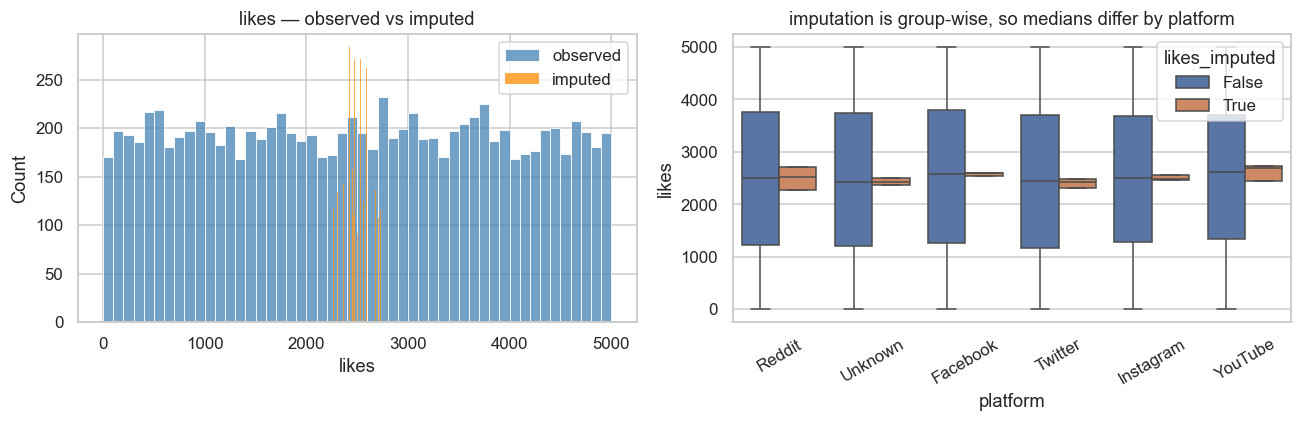

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(posts.loc[~posts["likes_imputed"], "likes"], bins=50, ax=axes[0],
             label="observed", color="steelblue")
sns.histplot(posts.loc[posts["likes_imputed"], "likes"], bins=50, ax=axes[0],
             label="imputed", color="darkorange")
axes[0].legend(); axes[0].set_title("likes — observed vs imputed")

sns.boxplot(data=posts, x="platform", y="likes", hue="likes_imputed", ax=axes[1])
axes[1].set_title("imputation is group-wise, so medians differ by platform")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(cfg.FIGURES_DIR / "02_imputation_effect.png", dpi=140)
plt.show()

In [17]:
comparison = pd.DataFrame({
    "observed only": posts.loc[~posts["likes_imputed"], "likes"].describe(),
    "all rows":      posts["likes"].describe(),
})
comparison.loc["imputed share"] = [0.0, posts["likes_imputed"].mean()]
comparison.round(2)

,observed only,all rows
count,9677.00,12000.00
mean,2493.51,2494.80
std,1438.29,1292.71
min,0.00,0.00
25%,1240.00,1547.00
50%,2502.00,2477.00
75%,3724.00,3450.00
max,5000.00,5000.00
imputed share,0.00,0.19


The mean barely moves; the **standard deviation contracts**, because 2,323 rows
now share a handful of identical median values. That is precisely why
`likes_imputed` is carried into the database and why every correlation in Phase 2
filters on it.

## 6. Outputs written

| File | Rows | Purpose |
|---|---:|---|
| `posts_clean.csv` / `.json` | 12,000 | primary cleaned dataset |
| `users_clean.csv` | 1,500 | normalised authors |
| `hashtags.csv` | 29 | tag vocabulary |
| `post_hashtags.csv` | 20,531 | many-to-many bridge |
| `cleaning_audit.csv` | 24 | machine-generated transformation log |

Next: `03_eda.ipynb`.